In [1]:
## Main modules 
using TDNEGF
using DifferentialEquations
using LinearAlgebra

println("Number of threads with JUlIA_NUM used in operations is : " , Threads.nthreads() )
println("Number of threads with BLAS used in operations is : " , BLAS.get_num_threads() )

Number of threads with JUlIA_NUM used in operations is : 1
Number of threads with BLAS used in operations is : 12


In [2]:
### Initialize params for electrons using block-based backend
function init_params_blocks(;Nx::Int=3, Ny::Int=2, Nσ::Int=2, N_orb::Int=1,
                     γ::Float64=1.0, γso=0.5 + 0.0im,Nα = 2,
                     N_λ1::Int=49, N_λ2::Int=20, β::Float64=33.0)
    Rλ, zλ = load_poles_square(N_λ1, N_λ2)
    p_model = ModelParamsTDNEGF(Nx = Nx, Ny = Ny, Nσ = Nσ, N_orb = N_orb,
                                Nα = Nα, N_λ1 = N_λ1, N_λ2 = N_λ2)

    H_ab    = build_H_ab(;Nx = p_model.Nx,Ny = p_model.Ny, Nσ = p_model.Nσ, N_orb = p_model.N_orb, γ = γ, γso = γso)
    Σᴸ_nλ   = build_Σᴸ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    Σᴳ_nλ   = build_Σᴳ_nλ(Rλ, zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    χ_nλ    = build_χ_nλ(zλ, p_model.Ny, p_model.Nσ, p_model.N_orb, p_model.N_λ1, p_model.N_λ2; β=β, γ=1.0)
    ξ_anR   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = p_model.Nx,y_coup = 1:p_model.Ny)
    ξ_anL   = build_ξ_an(p_model.Nx, p_model.Ny, p_model.Nσ, p_model.N_orb; xcol = 1,y_coup = 1:p_model.Ny)

    left_block  = SelfEnergyBlock(:left,  p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anL)
    right_block = SelfEnergyBlock(:right, p_model.Nc, p_model.N_λ1, p_model.N_λ2, Σᴸ_nλ, Σᴳ_nλ, χ_nλ, ξ_anR)
    blocks = [left_block, right_block]

    p_model.H_ab  .= H_ab
    p_model.H0_ab .= H_ab
    p_blocks = ExperimentalBlockRHSParams(p_model.H_ab, blocks, ComplexF64[0.0 + 0.0im, 0.0 + 0.0im], p_model)
    u0 = zeros(ComplexF64, p_blocks.dims_ρ_ab[1]^2 + p_blocks.aux_layout.total_size)

    return (p_model = p_model, p_blocks = p_blocks, u = u0)
end


init_params_blocks (generic function with 1 method)

In [3]:
using Sunny

### Initiallize params for classical spin (Note that sunny.jl package is used)
function init_params_heisenberg_llg(;Nx::Int=2,Ny::Int=2,j_ex::Float64=0.1,a0::Float64=1.0,j_ani::Float64=0.01,Bx::Float64=1e-5)

    latvecs   = lattice_vectors(a0, a0, 4*a0, 90, 90, 90)  # cúbica
    positions = [[0.5, 0.5, 0.0]] 

    # Define the symmtery of the crystal 
    cryst = Crystal(latvecs, positions)

    # Characterizes an effective spin magnetic moment on an atom
    # specification of spi moments
    moments = [1 => Moment(s=1.0, g=1.0)]
    # creates an instance of spin moments
    sys = System(cryst, moments, :dipole; dims=(Nx, Ny, 1)) 
    
    # Heisenberg interaction 
    set_field!(sys,[Bx,0.0,0.0])
    set_exchange!(sys, j_ex, Bond(1, 1, [1, 0, 0]))  # vecino +x
    set_exchange!(sys, j_ex, Bond(1, 1, [0, 1, 0]))  # vecino +y
    set_onsite_coupling!(sys, S ->  -j_ani*S[3]^2, 1)

   # set_onsite_coupling!(sys, S -> -Bx*S[1], 1)
    sys = to_inhomogeneous(sys)

    remove_periodicity!(sys, (true, true, true)) 
    
    ### Initial state
    if j_ex >= 0.0 #(+ is antiferro)
        for I in eachindex(sys.dipoles)
            i,j=ij_from_linear(I,Ny)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, (-1)^(i+j) )  
        end
    else  #(- is ferro)
        for I in eachindex(sys.dipoles)
            sys.dipoles[I] = Sunny.SVector(0.0, 0.0, 1.0)  ### AFM configuration
        end
    end
    return sys
end
@inline linear_index(i::Int, j::Int, Ny::Int) = (i - 1) * Ny + j
@inline function ij_from_linear(l::Int, Ny::Int)
    i = (l - 1) ÷ Ny + 1
    j = (l - 1) % Ny + 1
    return i, j
end

### Update the classical Hamiltonian
function update_H_s!(Nx::Int,Ny::Int,sys::System{0},σx_i::Array{Float64, 2}, j_sd::Float64,B0::Vector{Float64}=[0.0, 0.0, 0.0] )
    #B0 = sys.extfield[1,1,1,1] #### Take the global field
    @inbounds for i in 1:Nx for j in 1:Ny
        idx = linear_index(i,j,Ny) ### include the spin degree of freedom
        sden = -σx_i[idx,:]*j_sd
        set_field_at!(sys, sden .+ B0 ,(i , j, 1, 1)) 
        #println(i,j)
    end end
    return nothing 
end
# # sys = init_params_heisenberg_llg(j_ex=0.1)
# sys = init_params_heisenberg_llg(Nx = 2 ,Ny = 2, j_ex = 0.1)
# sys.dipoles

update_H_s! (generic function with 2 methods)

In [4]:
smooth_switch_on(t::Float64;ti=10.0) =t < 0.0 ? 0.0 : (t < ti ? sin((pi/2)*t/ti)^2 : 1) ;

smooth_pulse(t::Float64; ti::Float64=10.0, Δ::Float64=100.0) =
    t < 0.0 ? 0.0 :
    (t < ti ? sin((pi/2)*t/ti)^2 :
    (t < Δ ? 1.0 :
    (t < Δ + ti ? cos((pi/2)*(t-Δ)/ti)^2 : 0.0)))

smooth_pulse (generic function with 1 method)

In [5]:
function spin_dynamics_and_electrons_evolution(t_0::Float64, Δt::Float64 ,t_end::Float64;j_sd::Float64 = 0.1,
        j_ex::Float64 = 0.1,j_ani::Float64=0.1,Bx::Float64=0.0,u0=nothing,m0=nothing, p0 = nothing)
        
    println("Join the Main function")
    pstate = p0 === nothing ? init_params_blocks() : p0
    p_model = pstate.p_model
    p_blocks = pstate.p_blocks
    u = u0 === nothing ? copy(pstate.u) : u0

    m0 === nothing ? sys = init_params_heisenberg_llg(Nx = p_model.Nx ,Ny = p_model.Ny, j_ex = j_ex, j_ani = j_ani, Bx=Bx) : sys = m0

    # Main evolution now uses the block RHS and pointer_blocks observables.
    prob = ODEProblem(eom_tdnegf_blocks!, u, (t_0,t_end), p_blocks)
    intg = init(prob,Vern7(),dt = Δt, save_everystep=false,adaptive=true,dense=false)
    integ = Langevin(Δt ; damping=0.5, kT=0.0)
    println("The integrator has been set")

    N_steps = Int(round((t_end - t_0)/Δt))
    obs = ObservablesTDNEGF(p_model; N_tmax=N_steps , N_leads = length(p_blocks.blocks))
    site_ranges_couple = [get_sub(i, p_model.N_loc) for i in 1:p_model.N_sites]

    @time for i in 1:N_steps
        obs.idx = i
        DifferentialEquations.step!(intg, Δt, true)
        Sunny.step!(sys,integ)

        println("time: ", round(intg.t, digits=2))
        flush(stdout)

        dv = pointer_blocks(intg.u, p_blocks.dims_ρ_ab, p_blocks.aux_layout)
        ρ  = ρ_eq(0.0, 33.0, p_model.H_ab, p_model.N_λ2,p_model.Nx,p_model.Ny,p_model.Nσ,p_model.N_orb)

        obs.t[i] = intg.t
        obs_n_i!(dv, p_model, obs)
        obs_σ_i!(dv, p_model, obs)
        obs_Ixα!(dv, p_blocks, obs)
        obs_s_i!(sys.dipoles[:,:,1,1], p_model, obs)
        obs_σ_i_eq!(ρ, p_model, obs)

        update_H_s!(p_model.Nx,p_model.Ny,sys,obs.σx_i[:,:,i], j_sd)
        update_H_e!(p_model, site_ranges_couple, sys.dipoles[:,:,1,1], j_sd)
        Δ_left = smooth_pulse(intg.t .-100.0;ti=10.0,Δ=1000.0)*1.0 + 0im
        p_blocks.Δ_blocks[1] = +Δ_left
        p_blocks.Δ_blocks[2] = -Δ_left
    end

    return  obs, intg.u, sys, (p_model = p_model, p_blocks = p_blocks, u = intg.u)
end


spin_dynamics_and_electrons_evolution (generic function with 1 method)

In [6]:
obs,u0,m0,p0 = spin_dynamics_and_electrons_evolution(0.0,0.1,120.0; j_ex = -0.05,j_sd = 0.1) #(+ is antiferro /- is ferro)

Join the Main function
The integrator has been set

[ Info: Overriding coupling for Bond(1, 1, [0, 1, 0]).



time: 0.1
time: 0.2
time: 0.3
time: 0.4
time: 0.5
time: 0.6
time: 0.7
time: 0.8
time: 0.9
time: 1.0
time: 1.1
time: 1.2
time: 1.3
time: 1.4
time: 1.5
time: 1.6
time: 1.7
time: 1.8
time: 1.9
time: 2.0
time: 2.1
time: 2.2
time: 2.3
time: 2.4
time: 2.5
time: 2.6
time: 2.7
time: 2.8
time: 2.9
time: 3.0
time: 3.1
time: 3.2
time: 3.3
time: 3.4
time: 3.5
time: 3.6
time: 3.7
time: 3.8
time: 3.9
time: 4.0
time: 4.1
time: 4.2
time: 4.3
time: 4.4
time: 4.5
time: 4.6
time: 4.7
time: 4.8
time: 4.9
time: 5.0
time: 5.1
time: 5.2
time: 5.3
time: 5.4
time: 5.5
time: 5.6
time: 5.7
time: 5.8
time: 5.9
time: 6.0
time: 6.1
time: 6.2
time: 6.3
time: 6.4
time: 6.5
time: 6.6
time: 6.7
time: 6.8
time: 6.9
time: 7.0
time: 7.1
time: 7.2
time: 7.3
time: 7.4
time: 7.5
time: 7.6
time: 7.7
time: 7.8
time: 7.9
time: 8.0
time: 8.1
time: 8.2
time: 8.3
time: 8.4
time: 8.5
time: 8.6
time: 8.7
time: 8.8
time: 8.9
time: 9.0
time: 9.1
time: 9.2
time: 9.3
time: 9.4
time: 9.5
time: 9.6
time: 9.7
time: 9.8
time: 9.9
time: 10.

(ObservablesTDNEGF{Float64}([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999  …  119.09999999999751, 119.1999999999975, 119.2999999999975, 119.39999999999749, 119.49999999999748, 119.59999999999748, 119.69999999999747, 119.79999999999747, 119.89999999999746, 119.99999999999746], [0.009914977815708867 0.03865859762848082 … 0.9304509321344132 0.9304693662009336; 0.009914977815708863 0.03865858780223133 … 0.9265030660467525 0.9265096250248417; … ; 0.009914977815708867 0.03865858780223134 … 1.0731894020333654 1.0731958453353987; 0.009914977815708863 0.03865859762848081 … 1.0693000759066729 1.0692933601203216], [0.00030009842436751866 -1.5708685270413787e-10 -2.4892159874827235e-7; -0.00030009842436751877 -1.5708685269610347e-10 2.48921598747405e-7; … ; 0.00030009842436751877 1.5708685270460453e-10 2.489215987491397e-7; -0.00030009842436751877 1.570868527189029e-10 -2.48921598747405e-7;;; 0.0023029380681230654 -2.284029153034207e

In [7]:
obs1,u01,m01,p01 = spin_dynamics_and_electrons_evolution(obs.t[end],0.1,200.0; j_ex = -0.05,j_sd = 0.1,u0,m0,p0)

Join the Main function
The integrator has been set
time: 120.1
time: 120.2
time: 120.3
time: 120.4
time: 120.5
time: 120.6
time: 120.7
time: 120.8
time: 120.9
time: 121.0
time: 121.1
time: 121.2
time: 121.3
time: 121.4
time: 121.5
time: 121.6
time: 121.7
time: 121.8
time: 121.9
time: 122.0
time: 122.1
time: 122.2
time: 122.3
time: 122.4
time: 122.5
time: 122.6
time: 122.7
time: 122.8
time: 122.9
time: 123.0
time: 123.1
time: 123.2
time: 123.3
time: 123.4
time: 123.5
time: 123.6
time: 123.7
time: 123.8
time: 123.9
time: 124.0
time: 124.1
time: 124.2
time: 124.3
time: 124.4
time: 124.5
time: 124.6
time: 124.7
time: 124.8
time: 124.9
time: 125.0
time: 125.1
time: 125.2
time: 125.3
time: 125.4
time: 125.5
time: 125.6
time: 125.7
time: 125.8
time: 125.9
time: 126.0
time: 126.1
time: 126.2
time: 126.3
time: 126.4
time: 126.5
time: 126.6
time: 126.7
time: 126.8
time: 126.9
time: 127.0
time: 127.1
time: 127.2
time: 127.3
time: 127.4
time: 127.5
time: 127.6
time: 127.7
time: 127.8
time: 127.9
t

(ObservablesTDNEGF{Float64}([120.09999999999745, 120.19999999999744, 120.29999999999744, 120.39999999999743, 120.49999999999743, 120.59999999999742, 120.69999999999742, 120.79999999999741, 120.8999999999974, 120.9999999999974  …  199.09999999999297, 199.19999999999297, 199.29999999999296, 199.39999999999296, 199.49999999999295, 199.59999999999295, 199.69999999999294, 199.79999999999293, 199.89999999999293, 199.99999999999292], [0.9304873360497901 0.9305043205831578 … 0.9301993459719338 0.9301993423356387; 0.9265150572777437 0.9265192670867776 … 0.926006330290747 0.9260063259227848; … ; 1.0732054742608965 1.0732181144330795 … 1.0739936431559616 1.0739936497510185; 1.0692888854495963 1.069286949316109 … 1.0698002463367287 1.0698002476312676], [0.1057374418309768 0.054589584536537145 -0.00048556802091143103; -0.11276258686048396 0.04773130993405337 0.06408498733325729; … ; 0.11268520920320324 -0.047583656354208886 0.06403205640085796; -0.1058491672142107 -0.05441303619108822 -0.0005958954

In [8]:
using Plots, LaTeXStrings
gr()
default(linewidth = 2, framestyle = :box, grid = false,
        tickfontsize = 12, guidefontsize = 15, legendfontsize = 10,
        size = (700, 500), margin = 5Plots.mm)

In [9]:
### Lets plot the AFM against the FM configuration 
# Calculation of the average magnetization for FM configuration
function avg_M(dip::Array{Float64, 3},Nx::Int,Ny::Int)
    size_t   = size(dip)[3]
    size_sys = Nx*Ny#size(dip)[1]
    M_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            for x in 1:3
                M_t[x,t_idx] +=  dip[i ,x,t_idx]
            end
        end
    end
    return M_t/size_sys
end
# Calculation of the average Neel Vector for AFM configuration
function avg_N(dip::Array{Float64, 3},Nx::Int,Ny::Int)
                
    size_t   = size(dip)[3]
    size_sys = Nx*Ny
    N_t      = zeros(Float64,3,size_t)
    for t_idx in 1:size_t
        for i in 1:size_sys
            i_x,j_y = ij_from_linear(i,Ny)
            for x in 1:3
                N_t[x,t_idx] +=  dip[i ,x,t_idx]*(-1)^(i_x+j_y)
            end
        end
    end
    return N_t/size_sys

end

avg_N (generic function with 1 method)

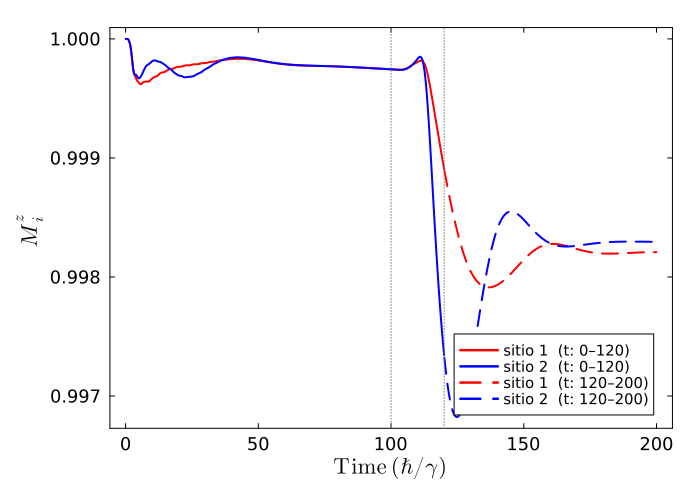

In [10]:
plt_s = plot(size = (700, 500), framestyle = :box, grid = false,
             tickfontsize = 12, guidefontsize = 15, legendfontsize = 10)

# Tramo 1 (obs): línea continua
plot!(plt_s, obs.t,  obs.sx_i[1,3,:],  c = :red,  ls = :solid, lw = 2, label = "sitio 1  (t: 0–120)")
plot!(plt_s, obs.t,  obs.sx_i[2,3,:],  c = :blue, ls = :solid, lw = 2, label = "sitio 2  (t: 0–120)")

# Tramo 2 (obs1): línea punteada
plot!(plt_s, obs1.t, obs1.sx_i[1,3,:], c = :red,  ls = :dash,  lw = 2, label = "sitio 1  (t: 120–200)")
plot!(plt_s, obs1.t, obs1.sx_i[2,3,:], c = :blue, ls = :dash,  lw = 2, label = "sitio 2  (t: 120–200)")

# Marcas de tiempo: encendido del bias y empalme de tramos
vline!(plt_s, [100.0, 120.0], c = :gray, ls = :dot, lw = 1, label = "")

plot!(plt_s,
      xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"M^{z}_{i}",
      legend = :bottomright)

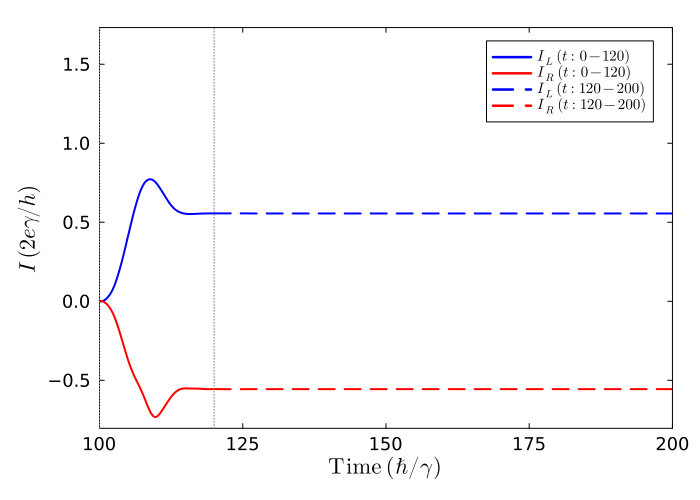

In [12]:
plt_I = plot(size = (700, 500), framestyle = :box, grid = false,
             tickfontsize = 12, guidefontsize = 15, legendfontsize = 10)

# Tramo 1 (obs): línea continua
plot!(plt_I, obs.t,  obs.Iα[1,:],  c = :blue, ls = :solid, lw = 2, label = L"I_L\ (t: 0\!-\!120)")
plot!(plt_I, obs.t,  obs.Iα[2,:],  c = :red,  ls = :solid, lw = 2, label = L"I_R\ (t: 0\!-\!120)")

# Tramo 2 (obs1): línea punteada
plot!(plt_I, obs1.t, obs1.Iα[1,:], c = :blue, ls = :dash,  lw = 2, label = L"I_L\ (t: 120\!-\!200)")
plot!(plt_I, obs1.t, obs1.Iα[2,:], c = :red,  ls = :dash,  lw = 2, label = L"I_R\ (t: 120\!-\!200)")

vline!(plt_I, [100.0, 120.0], c = :gray, ls = :dot, lw = 1, label = "")

plot!(plt_I,
      xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"I\ (2e\gamma/h)",
      xlims  = (100, 200),
      legend = :topright)

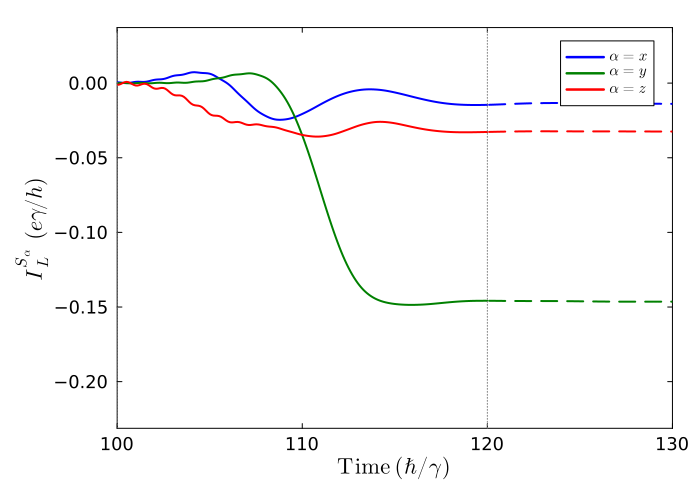

In [13]:
plt_Is = plot(size = (700, 500), framestyle = :box, grid = false,
              tickfontsize = 12, guidefontsize = 15, legendfontsize = 10)

# Tramo 1 (obs): línea continua
plot!(plt_Is, obs.t, obs.Iαx[1,1,:], c = :blue,  ls = :solid, lw = 2, label = L"\alpha = x")
plot!(plt_Is, obs.t, obs.Iαx[1,2,:], c = :green, ls = :solid, lw = 2, label = L"\alpha = y")
plot!(plt_Is, obs.t, obs.Iαx[1,3,:], c = :red,   ls = :solid, lw = 2, label = L"\alpha = z")

# Tramo 2 (obs1): línea punteada, mismos colores
plot!(plt_Is, obs1.t, obs1.Iαx[1,1,:], c = :blue,  ls = :dash, lw = 2, label = "")
plot!(plt_Is, obs1.t, obs1.Iαx[1,2,:], c = :green, ls = :dash, lw = 2, label = "")
plot!(plt_Is, obs1.t, obs1.Iαx[1,3,:], c = :red,   ls = :dash, lw = 2, label = "")

vline!(plt_Is, [100.0, 120.0], c = :gray, ls = :dot, lw = 1, label = "")

plot!(plt_Is,
      xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"I^{S_\alpha}_L\ (e\gamma/h)",
      xlims  = (100, 130),
      legend = :topright)

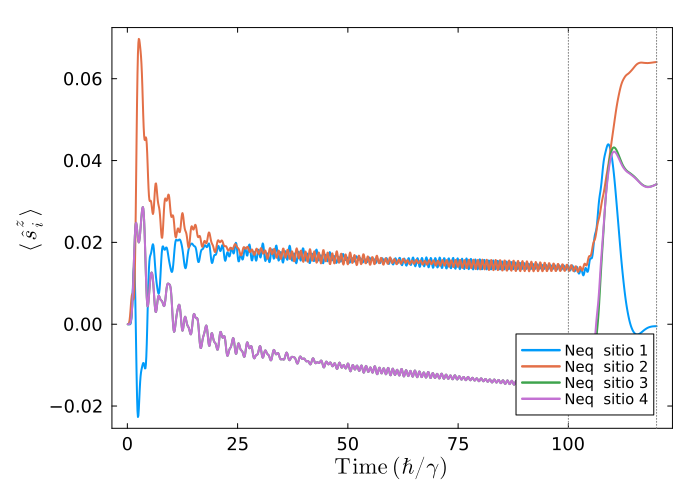

In [14]:
plt_σ = plot(size = (700, 500), framestyle = :box, grid = false,
             tickfontsize = 12, guidefontsize = 15, legendfontsize = 10)

for site in 1:4
    plot!(plt_σ, obs.t, obs.σx_i[site,3,:], lw = 2, label = "Neq  sitio $site")
end

vline!(plt_σ, [100.0, 120.0], c = :gray, ls = :dot, lw = 1, label = "")

plot!(plt_σ,
      xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"\langle \hat{s}^{z}_i \rangle",
      legend = :bottomright)

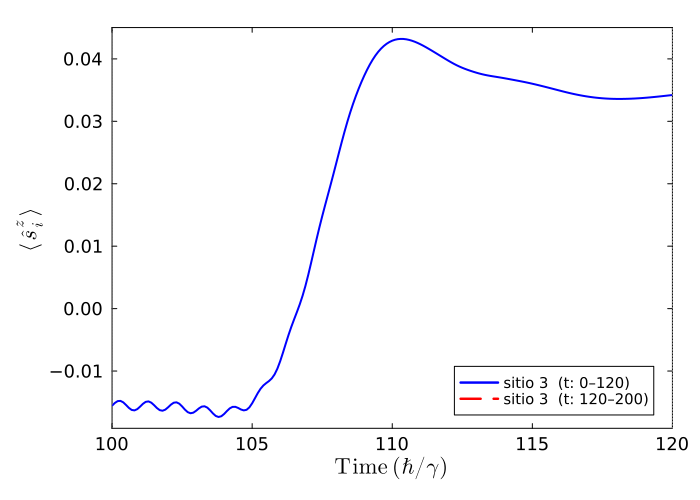

In [17]:
plt_σ3 = plot(size = (700, 500), framestyle = :box, grid = false,
              tickfontsize = 12, guidefontsize = 15, legendfontsize = 10)

plot!(plt_σ3, obs.t,  obs.σx_i[3,3,:],  c = :blue, ls = :solid, lw = 2, label = "sitio 3  (t: 0–120)")
plot!(plt_σ3, obs1.t, obs1.σx_i[3,3,:], c = :red,  ls = :dash,  lw = 2, label = "sitio 3  (t: 120–200)")

vline!(plt_σ3, [100.0, 120.0], c = :gray, ls = :dot, lw = 1, label = "")

plot!(plt_σ3,
      xlabel = L"\mathrm{Time}\ (\hbar/\gamma)",
      ylabel = L"\langle \hat{s}^{z}_i \rangle",
      xlims  = (100, 120),
      legend = :bottomright)